# Malli 2: Feature extraction VGG16

Käytämme esikoulutettua VGG16-mallia piirteiden irrottamiseen ja koulutamme oman luokittelijan päälle.

**Huom:** Notebook näyttää tulokset vasta sen jälkeen, kun solut on suoritettu. Aja solut järjestyksessä tai valitse `Run All`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))
sys.path.append(str(Path('..', 'src').resolve()))

from data_pipeline import create_generators
from models import build_feature_extraction_model
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = '../dataset/structured'
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)
EPOCHS = 10

train_gen, val_gen, test_gen = create_generators(DATA_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
NUM_CLASSES = len(train_gen.class_indices)
INPUT_SHAPE = (*IMAGE_SIZE, 3)

Found 149 images belonging to 2 classes.


Found 31 images belonging to 2 classes.


Found 34 images belonging to 2 classes.


In [3]:
model = build_feature_extraction_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [4]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1,
)

Epoch 1/10


 1/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7500 - loss: 0.6816

 2/10 ━━━━━━━━━━━━━━━━━━━━ 7s 911ms/step - accuracy: 0.7500 - loss: 2.1024

 3/10 ━━━━━━━━━━━━━━━━━━━━ 6s 921ms/step - accuracy: 0.7222 - loss: 3.6169

 4/10 ━━━━━━━━━━━━━━━━━━━━ 5s 907ms/step - accuracy: 0.7174 - loss: 4.0953

...

 7/10 ━━━━━━━━━━━━━━━━━━━━ 2s 910ms/step - accuracy: 0.9972 - loss: 0.0744

 8/10 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step - accuracy: 0.9956 - loss: 0.0771

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.9946 - loss: 0.0789

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.9938 - loss: 0.0803

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9866 - loss: 0.0926 - val_accuracy: 0.9032 - val_loss: 0.2243


In [5]:
test_loss, test_acc = model.evaluate(test_gen)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8750 - loss: 0.5471

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.9062 - loss: 0.4212

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9179 - loss: 0.3734

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.9412 - loss: 0.2779


Test loss: 0.2779
Test accuracy: 0.9412


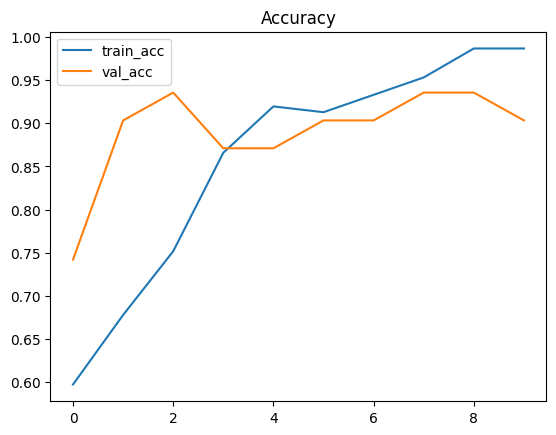

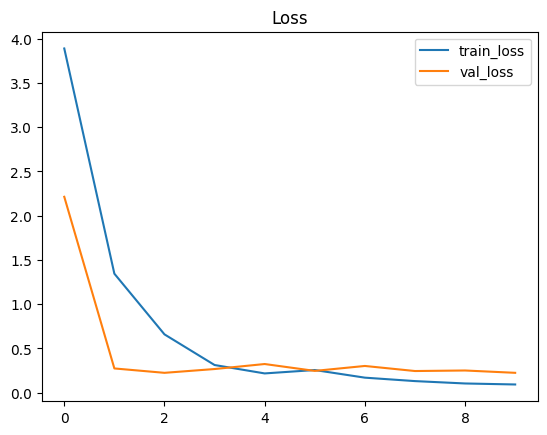

In [6]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()